<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/03_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from pathlib import Path

import json
import pandas as pd
import numpy as np

In [2]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

btc_data_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "BTCUSDT"
    / "lookback_30d"
)

In [4]:
X_val_raw = np.load(
    btc_data_dir / "X_val_raw.npy"
)

y_val = np.load(
    btc_data_dir / "y_val.npy"
)

validation_metadata = pd.read_parquet(
    btc_data_dir
    / "validation_metadata.parquet"
)

with open(
    btc_data_dir / "dataset_configuration.json",
    "r",
    encoding="utf-8"
) as file:
    configuration = json.load(file)

In [5]:
print("Loaded configuration:")
print("Candle interval:", configuration["candle_interval"])
print(
    "Variance definition:",
    configuration["variance_definition"]
)
print(
    "Lookback:",
    configuration["lookback_days"]
)
print(
    "Validation:",
    configuration["validation_start"],
    "to",
    configuration["validation_end"]
)

assert configuration["candle_interval"] == "1d"

assert (
    configuration["variance_definition"]
    == "squared_daily_log_return"
)

assert configuration["lookback_days"] == 30

Loaded configuration:
Candle interval: 1d
Variance definition: squared_daily_log_return
Lookback: 30
Validation: 2024-08-01 00:00:00+00:00 to 2025-07-31 00:00:00+00:00


In [6]:
assert (
    len(X_val_raw)
    == len(y_val)
    == len(validation_metadata)
)

print("X validation shape:", X_val_raw.shape)
print("y validation shape:", y_val.shape)

display(validation_metadata.head())

X validation shape: (365, 30, 7)
y validation shape: (365,)


,symbol,sequence_start_date,sequence_end_date,target_date,split,actual_rv
0,BTCUSDT,2024-07-02 00:00:00+00:00,2024-07-31 00:00:00+00:00,2024-08-01 00:00:00+00:00,validation,0.000125
1,BTCUSDT,2024-07-03 00:00:00+00:00,2024-08-01 00:00:00+00:00,2024-08-02 00:00:00+00:00,validation,0.003698
2,BTCUSDT,2024-07-04 00:00:00+00:00,2024-08-02 00:00:00+00:00,2024-08-03 00:00:00+00:00,validation,0.000172
3,BTCUSDT,2024-07-05 00:00:00+00:00,2024-08-03 00:00:00+00:00,2024-08-04 00:00:00+00:00,validation,0.001823
4,BTCUSDT,2024-07-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,2024-08-05 00:00:00+00:00,validation,0.005459


In [7]:
FEATURE_COLUMNS = configuration[
    "feature_columns"
]

for index, feature in enumerate(FEATURE_COLUMNS):
    print(index, feature)

0 log_realized_variance
1 daily_return
2 absolute_daily_return
3 high_low_range
4 log_volume
5 rv_mean_7d
6 rv_mean_30d


In [8]:
LOG_RV_INDEX = FEATURE_COLUMNS.index(
    "log_realized_variance"
)

RV_MEAN_7D_INDEX = FEATURE_COLUMNS.index(
    "rv_mean_7d"
)

RV_MEAN_30D_INDEX = FEATURE_COLUMNS.index(
    "rv_mean_30d"
)

In [9]:
actual_log_rv = y_val

actual_rv_from_y = np.exp(
    actual_log_rv
)

actual_rv = validation_metadata[
    "actual_rv"
].to_numpy()

assert np.allclose(
    actual_rv,
    actual_rv_from_y,
    rtol=1e-5,
    atol=1e-12
)

print("Target alignment verified.")

Target alignment verified.


In [10]:
last_observed_log_rv = X_val_raw[:, -1, LOG_RV_INDEX]

persistence_pred_rv = np.exp(
    last_observed_log_rv
)

In [11]:
mean_7d_pred_rv = X_val_raw[:, -1, RV_MEAN_7D_INDEX]

In [12]:
mean_30d_pred_rv = X_val_raw[:, -1, RV_MEAN_30D_INDEX]

In [13]:
def mean_absolute_error(
    y_true,
    y_pred
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(
        np.abs(y_true - y_pred)
    )

In [14]:
def root_mean_squared_error(
    y_true,
    y_pred
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )

In [15]:
def qlike(y_true, y_pred, epsilon=1e-12):

    y_true = np.maximum(
        np.asarray(y_true),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(y_pred),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )

In [16]:
def evaluate_forecast(model_name, y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    assert len(y_true) == len(y_pred)
    assert np.isfinite(y_true).all()
    assert np.isfinite(y_pred).all()
    assert (y_true > 0).all()
    assert (y_pred > 0).all()

    return {
        "model": model_name,
        "mae": mean_absolute_error(
            y_true,
            y_pred
        ),
        "rmse": root_mean_squared_error(
            y_true,
            y_pred
        ),
        "qlike": qlike(
            y_true,
            y_pred
        ),
    }

In [17]:
baseline_results = [
    evaluate_forecast(
        model_name="Persistence",
        y_true=actual_rv,
        y_pred=persistence_pred_rv
    ),
    evaluate_forecast(
        model_name="7-Day Mean RV",
        y_true=actual_rv,
        y_pred=mean_7d_pred_rv
    ),
    evaluate_forecast(
        model_name="30-Day Mean RV",
        y_true=actual_rv,
        y_pred=mean_30d_pred_rv
    ),
]

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values("qlike")
    .reset_index(drop=True)
)

baseline_results_df

,model,mae,rmse,qlike
0,30-Day Mean RV,0.000731,0.001355,1.878815
1,7-Day Mean RV,0.000768,0.001377,2.160473
2,Persistence,0.000892,0.001800,1878.685363


In [18]:
baseline_predictions_df = (
    validation_metadata[
        [
            "symbol",
            "sequence_end_date",
            "target_date",
            "actual_rv",
        ]
    ]
    .copy()
)

baseline_predictions_df[
    "actual_log_rv"
] = y_val

baseline_predictions_df[
    "persistence_pred_rv"
] = persistence_pred_rv

baseline_predictions_df[
    "mean_7d_pred_rv"
] = mean_7d_pred_rv

baseline_predictions_df[
    "mean_30d_pred_rv"
] = mean_30d_pred_rv

In [19]:
results_dir = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

baseline_results_df.to_csv(
    results_dir
    / "baseline_validation_metrics.csv",
    index=False
)

baseline_predictions_df.to_parquet(
    results_dir
    / "baseline_validation_predictions.parquet",
    index=False
)

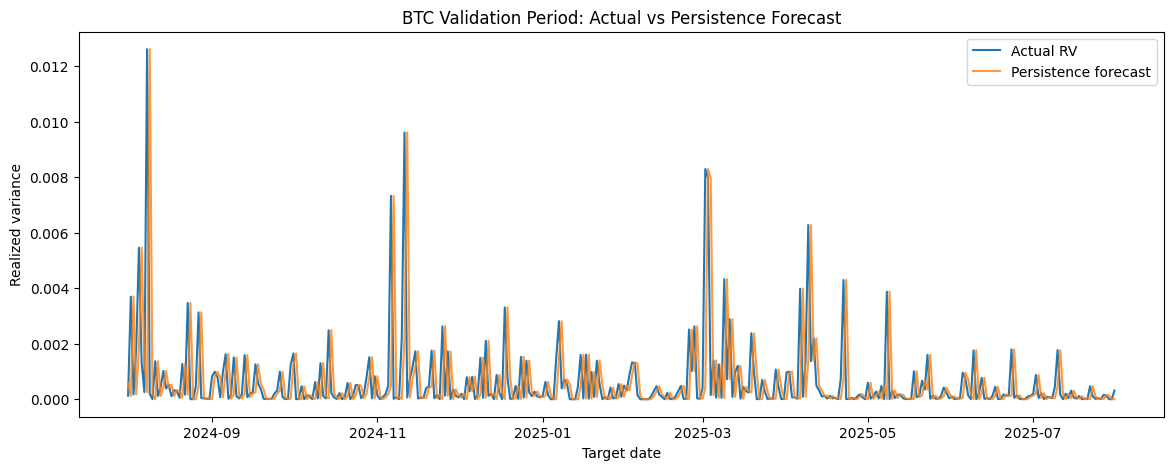

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    baseline_predictions_df["target_date"],
    baseline_predictions_df["actual_rv"],
    label="Actual RV"
)

plt.plot(
    baseline_predictions_df["target_date"],
    baseline_predictions_df[
        "persistence_pred_rv"
    ],
    label="Persistence forecast",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs Persistence Forecast"
)

plt.legend()
plt.show()

In [21]:
sanity_check_df = baseline_predictions_df[
    [
        "sequence_end_date",
        "target_date",
        "actual_rv",
        "persistence_pred_rv",
        "mean_7d_pred_rv",
        "mean_30d_pred_rv",
    ]
].head(10)

sanity_check_df

,sequence_end_date,target_date,actual_rv,persistence_pred_rv,mean_7d_pred_rv,mean_30d_pred_rv
0,2024-07-31 00:00:00+00:00,2024-08-01 00:00:00+00:00,0.000125,0.000569,0.000312,0.000593
1,2024-08-01 00:00:00+00:00,2024-08-02 00:00:00+00:00,0.003698,0.000125,0.000324,0.000592
2,2024-08-02 00:00:00+00:00,2024-08-03 00:00:00+00:00,0.000172,0.003698,0.000710,0.000682
3,2024-08-03 00:00:00+00:00,2024-08-04 00:00:00+00:00,0.001823,0.000172,0.000734,0.000591
4,2024-08-04 00:00:00+00:00,2024-08-05 00:00:00+00:00,0.005459,0.001823,0.000991,0.000650
5,2024-08-05 00:00:00+00:00,2024-08-06 00:00:00+00:00,0.001326,0.005459,0.001704,0.000806
6,2024-08-06 00:00:00+00:00,2024-08-07 00:00:00+00:00,0.000255,0.001326,0.001881,0.000793
7,2024-08-07 00:00:00+00:00,2024-08-08 00:00:00+00:00,0.012608,0.000255,0.001837,0.000794
8,2024-08-08 00:00:00+00:00,2024-08-09 00:00:00+00:00,0.000192,0.012608,0.003620,0.001196
9,2024-08-09 00:00:00+00:00,2024-08-10 00:00:00+00:00,0.000002,0.000192,0.003119,0.001201


In [22]:
manual_persistence = X_val_raw[
    :,
    -1,
    LOG_RV_INDEX
]

manual_persistence = np.exp(
    manual_persistence
)

assert np.allclose(
    manual_persistence,
    persistence_pred_rv
)

print("Persistence construction verified.")

Persistence construction verified.


In [23]:
print(
    "Exact matches:",
    np.isclose(
        actual_rv,
        persistence_pred_rv,
        rtol=1e-10,
        atol=1e-12
    ).sum()
)

print(
    "Correlation:",
    np.corrcoef(
        actual_rv,
        persistence_pred_rv
    )[0, 1]
)

Exact matches: 0
Correlation: 0.09567476988359318


In [24]:
print(
    "Mean actual RV:",
    actual_rv.mean()
)

print(
    "Persistence MAE / Mean RV:",
    mean_absolute_error(
        actual_rv,
        persistence_pred_rv
    ) / actual_rv.mean()
)

print(
    "7-day mean MAE / Mean RV:",
    mean_absolute_error(
        actual_rv,
        mean_7d_pred_rv
    ) / actual_rv.mean()
)

Mean actual RV: 0.0006212009755215034
Persistence MAE / Mean RV: 1.436102363154404
7-day mean MAE / Mean RV: 1.2360410166291806


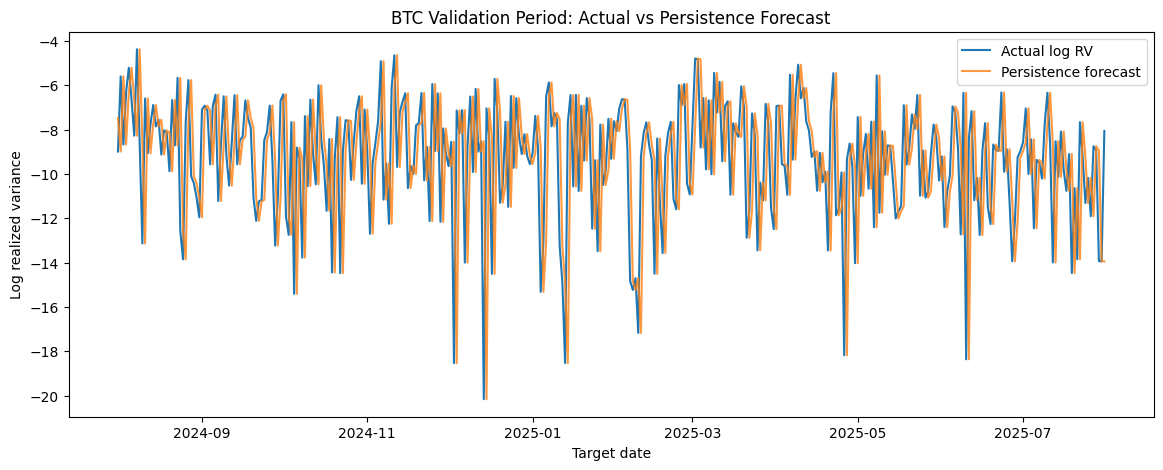

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    baseline_predictions_df["target_date"],
    np.log(
        baseline_predictions_df["actual_rv"]
    ),
    label="Actual log RV"
)

plt.plot(
    baseline_predictions_df["target_date"],
    np.log(
        baseline_predictions_df[
            "persistence_pred_rv"
        ]
    ),
    label="Persistence forecast",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Log realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs Persistence Forecast"
)

plt.legend()
plt.show()